NSE session: 200
Contract endpoint: 200

Available expiry candidates:
['06-Oct-2026', '13-Oct-2026', '19-Oct-2026', '27-Oct-2026', '03-Nov-2026', '23-Nov-2026', '29-Dec-2026', '30-Mar-2027', '29-Jun-2027', '28-Sep-2027']

Selected nearest expiry: 06-Oct-2026
Option-chain response: 200
NIFTY option-chain downloaded.

Response keys: ['records', 'filtered']
NIFTY Spot: 0.00

Contracts available: 0
Time to maturity: 0.01016 years

Valid IV observations: 0


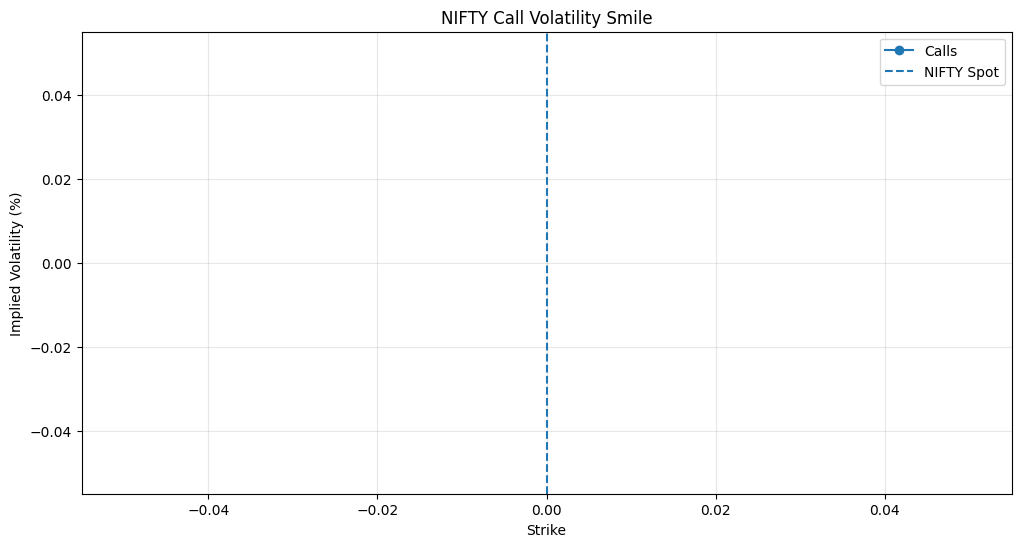

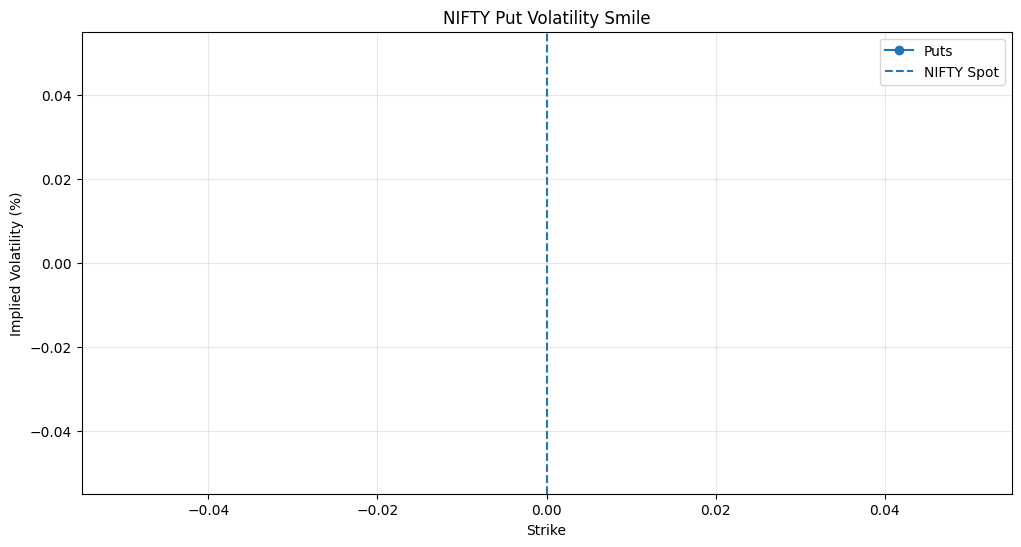

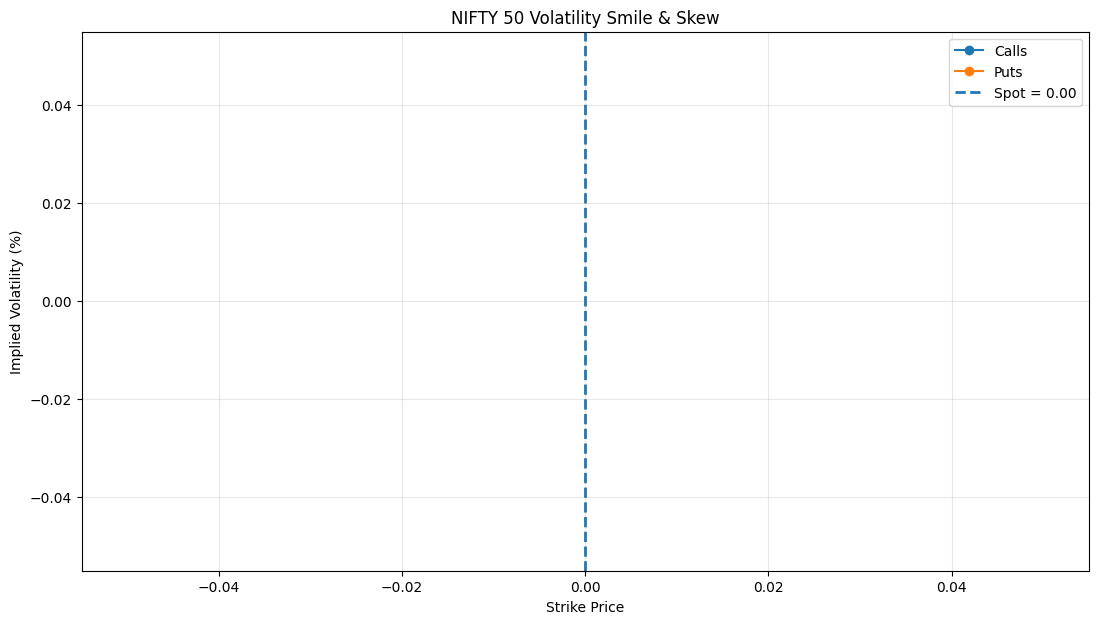


========== ATM IMPLIED VOLATILITY ==========

========== VOLATILITY SKEW ==========


,Moneyness,Put_IV,Call_IV,Put_Call_IV_Difference
0,95% Spot,NaN,NaN,NaN
1,ATM,NaN,NaN,NaN
2,105% Spot,NaN,NaN,NaN


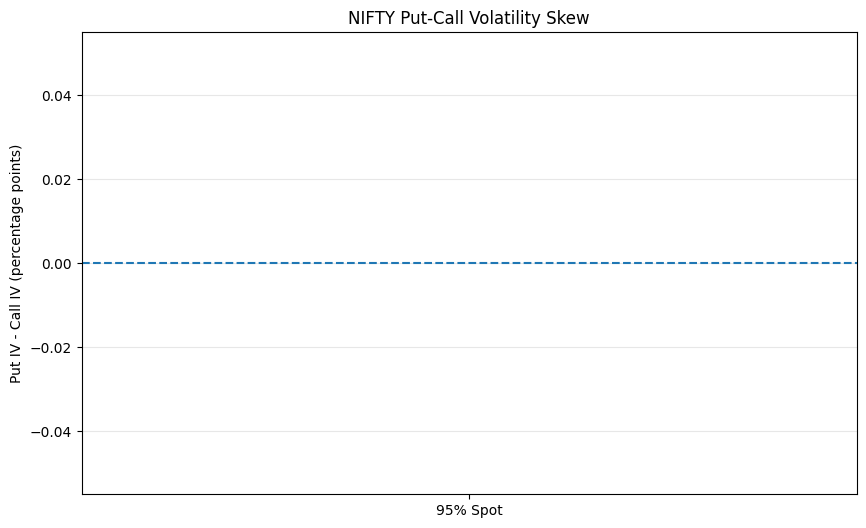


Files created:
1. NIFTY_Volatility_Smile_Skew.csv
2. NIFTY_Volatility_Skew_Summary.csv

PROJECT 1 COMPLETE
NIFTY Spot       : 0.00
Expiry           : 06-Oct-2026
Time to Maturity : 0.0102 years
Valid Contracts  : 0

Research outputs:
✓ Implied Volatility
✓ Volatility Smile
✓ Volatility Skew
✓ ATM IV
✓ Put-Call IV Difference
✓ CSV Export


In [2]:
# ============================================================
# PROJECT 1: NIFTY VOLATILITY SMILE & SKEW
# NSE OPTION-CHAIN-V3 VERSION
# ============================================================

!pip -q install requests pandas numpy scipy matplotlib

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime
import re
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. NSE SESSION
# ============================================================

session = requests.Session()

headers = {
    "User-Agent":
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/137.0.0.0 Safari/537.36",

    "Accept":
        "application/json, text/plain, */*",

    "Accept-Language":
        "en-US,en;q=0.9",

    "Referer":
        "https://www.nseindia.com/option-chain",

    "Connection":
        "keep-alive"
}

session.headers.update(headers)

# Establish NSE cookies
home = session.get(
    "https://www.nseindia.com/option-chain",
    timeout=20
)

print("NSE session:", home.status_code)

# ============================================================
# 2. GET NIFTY EXPIRIES
# ============================================================

contract_url = (
    "https://www.nseindia.com/api/"
    "option-chain-contract-info?symbol=NIFTY"
)

contract_response = session.get(
    contract_url,
    timeout=20
)

print(
    "Contract endpoint:",
    contract_response.status_code
)

if contract_response.status_code != 200:
    raise Exception(
        "NSE contract endpoint failed. "
        f"HTTP {contract_response.status_code}"
    )

contract_data = contract_response.json()

# ------------------------------------------------------------
# Try to locate expiry dates automatically
# ------------------------------------------------------------

def find_expiries(obj):

    found = []

    if isinstance(obj, dict):

        for key, value in obj.items():

            key_lower = str(key).lower()

            if "expiry" in key_lower:

                if isinstance(value, list):

                    for x in value:

                        if isinstance(x, str):
                            found.append(x)

            found.extend(find_expiries(value))

    elif isinstance(obj, list):

        for item in obj:
            found.extend(find_expiries(item))

    return found


expiry_candidates = list(
    dict.fromkeys(
        find_expiries(contract_data)
    )
)

# Keep only strings resembling dates
expiry_candidates = [
    x for x in expiry_candidates
    if re.search(
        r"\d{1,2}[-/][A-Za-z]{3,9}[-/]\d{4}"
        r"|\d{4}[-/]\d{1,2}[-/]\d{1,2}",
        x
    )
]

if not expiry_candidates:

    raise Exception(
        "Could not identify NIFTY expiry dates "
        "from NSE contract information."
    )

print("\nAvailable expiry candidates:")
print(expiry_candidates[:10])

# ============================================================
# 3. NORMALIZE EXPIRY
# ============================================================

def parse_expiry(x):

    formats = [
        "%d-%b-%Y",
        "%d-%B-%Y",
        "%d/%b/%Y",
        "%d/%B/%Y",
        "%Y-%m-%d",
        "%Y/%m/%d"
    ]

    for fmt in formats:

        try:
            return datetime.strptime(x, fmt)

        except:
            pass

    return None


parsed_expiries = []

for x in expiry_candidates:

    dt = parse_expiry(x)

    if dt is not None:
        parsed_expiries.append((dt, x))


parsed_expiries = sorted(
    parsed_expiries,
    key=lambda x: x[0]
)

today = datetime.now()

future_expiries = [
    x for x in parsed_expiries
    if x[0].date() >= today.date()
]

if not future_expiries:

    raise Exception(
        "No future NIFTY expiry found."
    )

expiry_dt, expiry = future_expiries[0]

print(
    "\nSelected nearest expiry:",
    expiry
)

# ============================================================
# 4. DOWNLOAD NIFTY OPTION CHAIN
# ============================================================

chain_url = (
    "https://www.nseindia.com/api/"
    "option-chain-v3"
)

params = {
    "type": "Indices",
    "symbol": "NIFTY",
    "expiry": expiry
}

response = session.get(
    chain_url,
    params=params,
    timeout=20
)

print(
    "Option-chain response:",
    response.status_code
)

if response.status_code != 200:

    raise Exception(
        "NSE option-chain-v3 failed. "
        f"HTTP {response.status_code}\n"
        f"URL: {response.url}"
    )

chain = response.json()

print("NIFTY option-chain downloaded.")

# ============================================================
# 5. INSPECT RESPONSE
# ============================================================

print(
    "\nResponse keys:",
    list(chain.keys())
)

# ============================================================
# 6. FIND OPTION DATA
# ============================================================

if "records" in chain:

    records = chain["records"]

elif "data" in chain:

    records = chain["data"]

else:

    records = chain

# ============================================================
# 7. EXTRACT SPOT
# ============================================================

spot = None

def recursive_find_spot(obj):

    if isinstance(obj, dict):

        for key, value in obj.items():

            if str(key).lower() in [
                "underlyingvalue",
                "underlying_value",
                "spotprice",
                "spot_price"
            ]:

                if isinstance(value, (int, float)):
                    return float(value)

            result = recursive_find_spot(value)

            if result is not None:
                return result

    elif isinstance(obj, list):

        for item in obj:

            result = recursive_find_spot(item)

            if result is not None:
                return result

    return None


spot = recursive_find_spot(chain)

if spot is None:

    raise Exception(
        "Could not extract NIFTY spot price."
    )

print(
    f"NIFTY Spot: {spot:.2f}"
)

# ============================================================
# 8. EXTRACT OPTION ROWS
# ============================================================

rows = []

def process_records(obj):

    if isinstance(obj, list):

        for item in obj:
            process_records(item)

    elif isinstance(obj, dict):

        # Search for strike price
        strike = None

        for key in [
            "strikePrice",
            "strike_price",
            "strike"
        ]:

            if key in obj:

                try:
                    strike = float(obj[key])
                except:
                    pass

        # Search CE / PE
        ce = (
            obj.get("CE")
            or obj.get("ce")
            or obj.get("call")
        )

        pe = (
            obj.get("PE")
            or obj.get("pe")
            or obj.get("put")
        )

        if strike is not None:

            # ---------------- CALL ----------------

            if isinstance(ce, dict):

                rows.append({
                    "strike": strike,
                    "option_type": "CE",
                    "ltp": ce.get(
                        "lastPrice",
                        ce.get("ltp")
                    ),
                    "bid": ce.get(
                        "bidprice",
                        ce.get("bidPrice")
                    ),
                    "ask": ce.get(
                        "askPrice",
                        ce.get("askprice")
                    ),
                    "iv_nse": ce.get(
                        "impliedVolatility",
                        ce.get("iv")
                    ),
                    "volume": ce.get(
                        "totalTradedVolume",
                        ce.get("volume")
                    ),
                    "oi": ce.get(
                        "openInterest",
                        ce.get("oi")
                    )
                })

            # ---------------- PUT ----------------

            if isinstance(pe, dict):

                rows.append({
                    "strike": strike,
                    "option_type": "PE",
                    "ltp": pe.get(
                        "lastPrice",
                        pe.get("ltp")
                    ),
                    "bid": pe.get(
                        "bidprice",
                        pe.get("bidPrice")
                    ),
                    "ask": pe.get(
                        "askPrice",
                        pe.get("askprice")
                    ),
                    "iv_nse": pe.get(
                        "impliedVolatility",
                        pe.get("iv")
                    ),
                    "volume": pe.get(
                        "totalTradedVolume",
                        pe.get("volume")
                    ),
                    "oi": pe.get(
                        "openInterest",
                        pe.get("oi")
                    )
                })

        else:

            for value in obj.values():
                process_records(value)


process_records(chain)

options = pd.DataFrame(rows)

if options.empty:

    raise Exception(
        "No option contracts were extracted. "
        "NSE may have changed the response structure."
    )

# ============================================================
# 9. CLEAN DATA
# ============================================================

options["ltp"] = pd.to_numeric(
    options["ltp"],
    errors="coerce"
)

options["strike"] = pd.to_numeric(
    options["strike"],
    errors="coerce"
)

options["volume"] = pd.to_numeric(
    options["volume"],
    errors="coerce"
)

options["oi"] = pd.to_numeric(
    options["oi"],
    errors="coerce"
)

options = options[
    (options["ltp"] > 0) &
    (options["strike"] > 0)
].copy()

# Keep ±15% around spot
options = options[
    (options["strike"] >= spot * 0.85) &
    (options["strike"] <= spot * 1.15)
].copy()

options.reset_index(
    drop=True,
    inplace=True
)

print(
    f"\nContracts available: {len(options)}"
)

# ============================================================
# 10. TIME TO MATURITY
# ============================================================

T = (
    expiry_dt - datetime.now()
).total_seconds() / (
    365 * 24 * 60 * 60
)

T = max(T, 1 / 365)

print(
    f"Time to maturity: {T:.5f} years"
)

# ============================================================
# 11. BLACK-SCHOLES
# ============================================================

def bs_price(
    S,
    K,
    T,
    r,
    sigma,
    option_type
):

    if sigma <= 0 or T <= 0:
        return np.nan

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (
        sigma * np.sqrt(T)
    )

    d2 = (
        d1 - sigma * np.sqrt(T)
    )

    if option_type == "CE":

        return (
            S * norm.cdf(d1)
            - K * np.exp(-r*T) * norm.cdf(d2)
        )

    return (
        K * np.exp(-r*T) * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )

# ============================================================
# 12. IMPLIED VOLATILITY
# ============================================================

def calculate_iv(
    market_price,
    S,
    K,
    T,
    r,
    option_type
):

    if pd.isna(market_price):
        return np.nan

    if market_price <= 0:
        return np.nan

    def objective(sigma):

        return (
            bs_price(
                S,
                K,
                T,
                r,
                sigma,
                option_type
            )
            - market_price
        )

    try:

        return brentq(
            objective,
            0.0001,
            5.0
        )

    except:

        return np.nan

# ============================================================
# 13. RISK-FREE RATE
# ============================================================

r = 0.065

# ============================================================
# 14. CALCULATE IV
# ============================================================

options["iv"] = options.apply(
    lambda x: calculate_iv(
        x["ltp"],
        spot,
        x["strike"],
        T,
        r,
        x["option_type"]
    ),
    axis=1
)

options["iv_pct"] = (
    options["iv"] * 100
)

# Remove unrealistic values
options = options[
    (options["iv"] > 0.01) &
    (options["iv"] < 3.0)
].copy()

# ============================================================
# 15. CALLS / PUTS
# ============================================================

calls = options[
    options["option_type"] == "CE"
].sort_values("strike")

puts = options[
    options["option_type"] == "PE"
].sort_values("strike")

print(
    "\nValid IV observations:",
    len(options)
)

# ============================================================
# 16. CALL VOLATILITY SMILE
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    calls["strike"],
    calls["iv_pct"],
    marker="o",
    label="Calls"
)

plt.axvline(
    spot,
    linestyle="--",
    label="NIFTY Spot"
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.title(
    "NIFTY Call Volatility Smile"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 17. PUT VOLATILITY SMILE
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    puts["strike"],
    puts["iv_pct"],
    marker="o",
    label="Puts"
)

plt.axvline(
    spot,
    linestyle="--",
    label="NIFTY Spot"
)

plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.title(
    "NIFTY Put Volatility Smile"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 18. COMBINED SMILE + SKEW
# ============================================================

plt.figure(figsize=(13,7))

plt.plot(
    calls["strike"],
    calls["iv_pct"],
    marker="o",
    label="Calls"
)

plt.plot(
    puts["strike"],
    puts["iv_pct"],
    marker="o",
    label="Puts"
)

plt.axvline(
    spot,
    linestyle="--",
    linewidth=2,
    label=f"Spot = {spot:.2f}"
)

plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")

plt.title(
    "NIFTY 50 Volatility Smile & Skew"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 19. ATM IV
# ============================================================

options["distance"] = (
    abs(options["strike"] - spot)
)

atm = (
    options
    .sort_values("distance")
    .groupby("option_type")
    .first()
)

print("\n========== ATM IMPLIED VOLATILITY ==========")

for typ in ["CE", "PE"]:

    if typ in atm.index:

        print(
            typ,
            ":",
            round(
                atm.loc[typ, "iv_pct"],
                2
            ),
            "%"
        )

# ============================================================
# 20. 95% / 100% / 105% MONEINESS
# ============================================================

def nearest_iv(df, target):

    if df.empty:
        return np.nan, np.nan

    idx = (
        abs(df["strike"] - target)
    ).idxmin()

    return (
        df.loc[idx, "strike"],
        df.loc[idx, "iv_pct"]
    )


call_95 = nearest_iv(
    calls,
    spot * 0.95
)

call_atm = nearest_iv(
    calls,
    spot
)

call_105 = nearest_iv(
    calls,
    spot * 1.05
)

put_95 = nearest_iv(
    puts,
    spot * 0.95
)

put_atm = nearest_iv(
    puts,
    spot
)

put_105 = nearest_iv(
    puts,
    spot * 1.05
)

# ============================================================
# 21. SKEW TABLE
# ============================================================

skew_table = pd.DataFrame({

    "Moneyness": [
        "95% Spot",
        "ATM",
        "105% Spot"
    ],

    "Put_IV": [
        put_95[1],
        put_atm[1],
        put_105[1]
    ],

    "Call_IV": [
        call_95[1],
        call_atm[1],
        call_105[1]
    ]
})

skew_table[
    "Put_Call_IV_Difference"
] = (
    skew_table["Put_IV"]
    - skew_table["Call_IV"]
)

print(
    "\n========== VOLATILITY SKEW =========="
)

display(
    skew_table.round(2)
)

# ============================================================
# 22. SKEW CHART
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(
    skew_table["Moneyness"],
    skew_table[
        "Put_Call_IV_Difference"
    ]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel(
    "Put IV - Call IV (percentage points)"
)

plt.title(
    "NIFTY Put-Call Volatility Skew"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# ============================================================
# 23. EXPORT DATA
# ============================================================

options.to_csv(
    "NIFTY_Volatility_Smile_Skew.csv",
    index=False
)

skew_table.to_csv(
    "NIFTY_Volatility_Skew_Summary.csv",
    index=False
)

print(
    "\nFiles created:"
)

print(
    "1. NIFTY_Volatility_Smile_Skew.csv"
)

print(
    "2. NIFTY_Volatility_Skew_Summary.csv"
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n==============================================")
print("PROJECT 1 COMPLETE")
print("==============================================")

print(f"NIFTY Spot       : {spot:.2f}")
print(f"Expiry           : {expiry}")
print(f"Time to Maturity : {T:.4f} years")
print(f"Valid Contracts  : {len(options)}")

print("\nResearch outputs:")
print("✓ Implied Volatility")
print("✓ Volatility Smile")
print("✓ Volatility Skew")
print("✓ ATM IV")
print("✓ Put-Call IV Difference")
print("✓ CSV Export")

print("==============================================")